In [1]:
import torch
import pandas as pd
from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib import ticker 

torch.manual_seed(42)

from dataclass import dataset
import mcmc

$$
\begin{array}{|c|l|c|c|}
\hline
 & \text{Reaction} & \text{Stoichiometry} & \text{Rate} \\
\hline
\text{Colonization} & \emptyset \to E & +1 & \alpha \\
\hline
\text{Replication} & E \to 2E & +1 & \mu E \\
\hline
\text{Competition} & E \to \emptyset & -1 & \left(\frac{\mu}{K}\right) E^2 \\
\hline
\text{Expulsion} & E \to \emptyset & -1 & dE \\
\hline
\end{array}
$$


In [2]:
# Loading the synthetic dataset
dseed = 0
df = pd.read_csv('synthetic_data/synth_seed{}.csv'.format(dseed))
df

,Time,Counts,Dilution
0,24.0,5,20.0
1,24.0,0,20.0
2,24.0,0,20.0
3,24.0,4,20.0
4,24.0,15,20.0
...,...,...,...
395,168.0,102,2000.0
396,168.0,129,2000.0
397,168.0,118,2000.0
398,168.0,94,2000.0


In [3]:
#Loading the ground truth

gt = pd.read_csv('synthetic_data/gt_map.csv', header=None, delim_whitespace=True).to_numpy()
gt = torch.tensor(gt[gt[:,0]==dseed][0,1:]).float()
gt

tensor([5.0000e-02, 2.5000e-01, 2.0000e+05, 1.0000e-03])

In [4]:
# The dataset need to be send to the `dataset` class
Ts     = df['Time'].to_numpy()
counts = df['Counts'].to_numpy()
dils   = df['Dilution'].to_numpy()
data = dataset(Ts,counts,dils)


logposterior = lambda x: mcmc.logposterior(x,data) 
logposterior = lambda x: data.loglike(x)

Dataset loaded successfully.


In [5]:
lp_gt = logposterior(gt.to(data.device))
lp_gt

tensor(3.4598, device='cuda:0', dtype=torch.float64)

In [6]:
params = mcmc.prior.sample()

params = data.ode_initialization(params)
lp = logposterior(params)

Initializing using mass-action similarity


  5%|▌         | 10/200 [00:04<01:31,  2.07it/s]

gradient: 0.006964059546589851 0.043441106146247244


 10%|█         | 20/200 [00:09<01:20,  2.23it/s]

gradient: 0.014402405358850956 0.032750846894274696


...

gradient: 2.857111940102186e-05 0.028951085637953233


 80%|████████  | 160/200 [01:05<00:14,  2.72it/s]

gradient: 1.3231176126282662e-05 0.028951081998565345


 84%|████████▍ | 169/200 [01:09<00:12,  2.43it/s]

gradient: 4.3633835957734846e-06 0.028951082655115163


In [7]:
initial_guess=params 

n_burn1=200 
n_burn2=0
n_mcmc=2000 
# window=200
# update_every=10
    
dim = 4
params = initial_guess.clone().detach()#.double()
lp = logposterior(params)

mcmc_params = []
mcmc_lps = []

L = 1e-2 *torch.tensor((1,1,1,5),device=data.device)  # scalar proposal for burn1
#cov_init = 1e-4*torch.eye(dim).to(data.device)

total_steps = n_burn1 + n_burn2 + n_mcmc

In [8]:
greedy = False
for s in tqdm(range(total_steps)):
    # ---- Burn-in 1: scalar proposal, greedy ----
    # if s < n_burn1:
    #     L = 1e-2 #make l_pre torch.linspace(.1,.01,n_burn1)
    #     greedy = True

    # # ---- Burn-in 2: adaptive proposal, MH ----
    # elif s < n_burn1 + n_burn2:
    #     greedy = False

    #     if (s % update_every == 0) or last_cov is None:
    #         g = max(s-n_burn1,s-window) #ignore greed samples
    #         log_samples = torch.stack([torch.log(p) for p in mcmc_params[g:]])
    #         cov_emp = torch.cov(log_samples.T)

    #         alpha = len(log_samples) / window # transition weight
    #         cov = alpha * cov_emp + (1 - alpha) * cov_init
    #         scaled_cov = (2.38 ** 2) / dim * cov

    #         try:
    #             L = torch.linalg.cholesky(scaled_cov + 1e-6 * torch.eye(dim,device=data.device))
    #             last_cov = cov.clone()
    #         except RuntimeError:
    #             print(f"[{s}] Cholesky failed — fallback L.")
    #             L = torch.eye(dim,device=data.device) * 1e-2

        
    greedy = s < n_burn1

    # ---- Step and store ----
    params, lp = mcmc.next_MCMC_sample(logposterior,params, lp, L=L, greedy=greedy)
    mcmc_params.append(params*1)
    mcmc_lps.append(lp.item())

    if (s + 1) % 10 == 0:
        print(f"[{s+1}] lp = {lp.item():.3f}")
        print(params.cpu())




  0%|          | 10/2200 [01:01<3:59:58,  6.57s/it]

[10] lp = 3.098
tensor([7.3176e-02, 2.9815e-01, 1.9867e+05, 2.5288e-04])


  1%|          | 20/2200 [01:54<3:22:45,  5.58s/it]

[20] lp = 3.164
tensor([7.2987e-02, 2.5788e-01, 2.0182e+05, 2.7147e-04])


  1%|▏         | 30/2200 [03:10<4:23:54,  7.30s/it]

...

[2180] lp = 4.032
tensor([5.4455e-02, 1.1556e-02, 2.0381e+05, 1.1950e-05])


100%|█████████▉| 2190/2200 [17:57<00:01,  5.62it/s]

[2190] lp = 4.031
tensor([5.3960e-02, 1.3349e-02, 2.0984e+05, 1.1163e-05])


100%|██████████| 2200/2200 [17:58<00:00,  2.04it/s]

[2200] lp = 4.027
tensor([5.4729e-02, 1.5946e-02, 2.1278e+05, 1.2473e-05])


In [10]:
posterior_samples = torch.stack(mcmc_params[-n_mcmc:]).cpu().numpy()

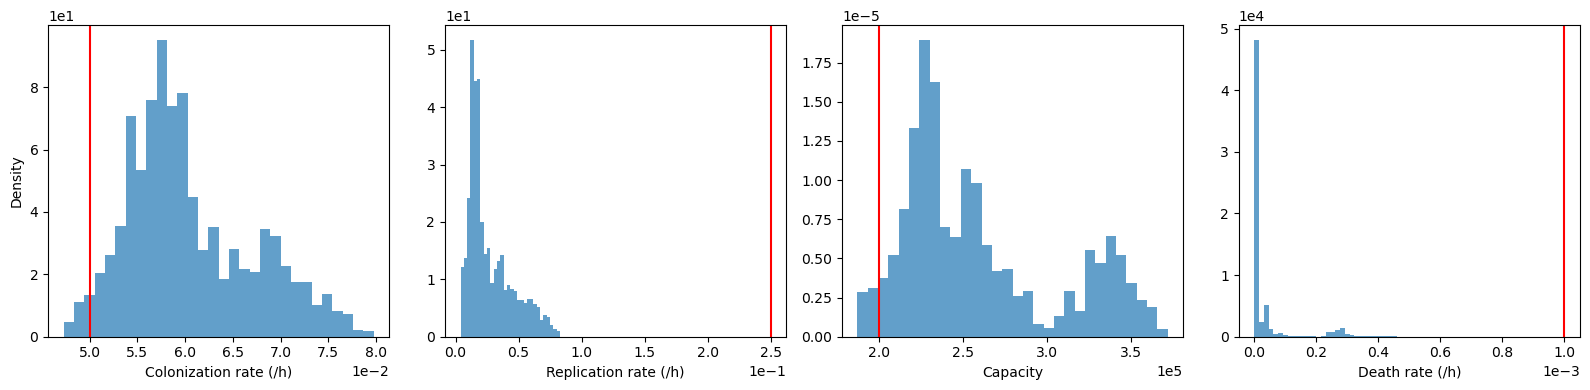

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Colonization rate (/h)','Replication rate (/h)','Capacity','Death rate (/h)']
for i in range(4):
    ax[i].hist(posterior_samples[:, i], bins=30, density=True, alpha=0.7)
    ax[i].set_xlabel(titles[i])
    ax[i].axvline(gt[i].item(),color='r')

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
[axi.ticklabel_format(style='sci', axis='y', scilimits=(0, 0)) for axi in ax]
[axi.ticklabel_format(style='sci', axis='x', scilimits=(0, 0)) for axi in ax]

ax[0].set_ylabel('Density')
fig.tight_layout()
plt.show()

Text(0, 0.5, 'Log posterior')

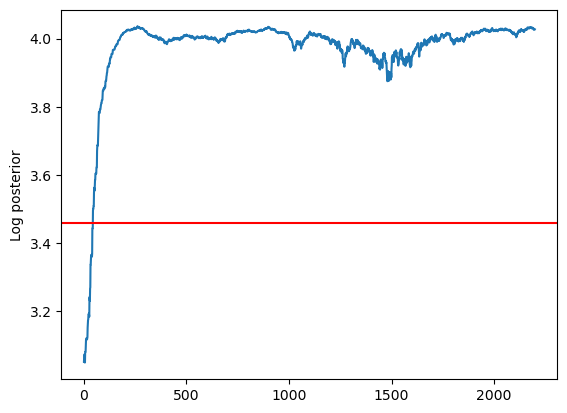

In [12]:
plt.plot(mcmc_lps)
plt.axhline(lp_gt.item(),color='r')
plt.ylabel('Log posterior')